In [41]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics
import seaborn as sn

In [42]:
col_names = ['Serial No.', 'GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR ', 'CGPA', 'Research', 'Chance of Admit', 'Admit']

import pandas as pd

# Read the CSV (no header)
df = pd.read_csv("Admission_Predict.csv", header=None)

# Add a new column:
# 1 if last column > 0.4, else 0
df[df.columns[-1] + 1] = (df.iloc[:, -1] > 0.8).astype(int)

# Save the new CSV without headers or index
df.to_csv("Admission_Predict_Binary.csv", index=False, header=False)

data = pd.read_csv('Admission_Predict_Binary.csv', header=None, names=col_names)

print(data.shape)


(500, 10)


In [43]:
data.isnull().sum()

Serial No.           0
GRE Score            0
TOEFL Score          0
University Rating    0
SOP                  0
LOR                  0
CGPA                 0
Research             0
Chance of Admit      0
Admit                0
dtype: int64

In [44]:
features = ['GRE Score', 'University Rating', 'CGPA']
x = data[features]
y = data['Admit']

In [45]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=5)

In [46]:
model = LogisticRegression(solver='lbfgs', max_iter=1000)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

[[72  3]
 [ 3 22]]
Accuracy: 0.94


<Axes: xlabel='Predicted', ylabel='Actual'>

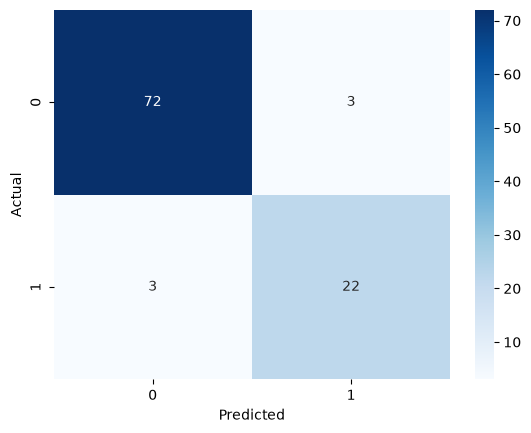

In [47]:
conf_matrix = metrics.confusion_matrix(y_test, y_pred)
print(conf_matrix)

accuracy_score = metrics.accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy_score)

conf_mat = pd.crosstab(y_test, y_pred, rownames=['Actual'], colnames=['Predicted'])
sn.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues')